# Autograd Implementation.
 This is my personal implementation and study guide built while following Andrej Karpathy's micrograd. All core architectural concepts credit the original author

This is a tool which allows for building mathematical expressions:
```
a = Value(4.0)
b = Value(-2.0)
c = a + b
f = c / 2.0
print(f'{f.data::.4f}') # prints the value of f as a result of the forward pass
f.backward() ## initialises backpropagartion at node f
print(f'{a.grad:.4f}') # numerical value of the derivative df/da
```
So it keeps track of all mathematical expressions and helps in automating dervatives etc.

In [ ]:
# some basic imports
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# This is a simple function representing a mathematical transformation of taking a scalar x and returning a scalar y
def f(x):
  return 3*(x**2) - 4*x + 5
f(3)

In [ ]:
# Now we visualize this function, since this is just a mathematical expression with degree 2 it will most likely be a parabola
xs = np.arange(-5, 5, 0.25) # returns a list of values from -5 to 5 with steps of 0.25
ys = f(xs)
plt.plot(xs,ys)

In [ ]:
# Let's say we need to find the derivative of this function, given an input x what is the slope of f(x), we can define one hardcodeed manual function for this
def df(x):
  return 6*x - 4
df(3)

The above approach cannot be done in neural networks especially in backpropagation as there are thousands of weights and the expression will be giant and it will not be practical to hardcode. Instead to solve this for nns, we look at the very definition of a derivative. The expression for a derivative is:

$ L = lim_{h -> 0} \frac{f(x+h) - f(x)}{h}$

This means that given an input x if we nudge the function in the positive direction with an infinitesmally small value h how will it react, will the value increase or decrease relative to the size of h.

In [ ]:
# This basically looks like:
h = 0.0001 # there are limitations in representing really small values in computers
x = 3
((f(x+h) - f(x)))/h

In [ ]:
# Making things a bit more complex, for any function with multiple scalar inputs how do we calculate derivative of the function wrt each input

# inputs
a = 4
b = -3
c = 5

# function
f = a*b + c
f1 = f
print("f1",f1)
a+=h
f2 = a*b + c
print("f2",f2)
print("slope ",(f2-f1)/h) # df/da since we are only nudging a slightly, slope will be negative meaning increasing a will decrease f because a is multiplied by b which is -ve
c += h
a -= h
f3 = a*b + c
print("slope wrt c",(f3-f1)/h) # this should be closer to 1 since c doesn't have any coefficient and is only being added to f

## Value Object Abstraction
In neural networks, it is hard to keep track of all the variables so we need a way store mathematical expressions of a variable and be able to calculate derivatives of a variable wrt to all the other variables that make it up. So we create this Value class to represent these mathematic functions

In [60]:
class Value:

  def __init__(self,data,label='',_op='',_children=()):
    self.data = data
    self._prev = set(_children)
    self.label = label # keep track of identifier
    self._op = _op # the operation on the children variables that result in this
    self.grad = 0 # gradient meant to keep track of derivative of this wrt its children
    self._backward = lambda: None

  def __repr__(self):
    return f"Value(data:{self.data},label:{self.label},op:{self._op},children:{self._prev})"

  def __add__(self,other):
    other = other if isinstance(other,Value) else Value(other) # so that a + 1 can work with constants where since 1 is not instance of Value we wrap it into Value(1)
    out = Value(self.data + other.data,'','+',(self,other))
    def _backward():
      self.grad += 1 * out.grad # += not = : a variable is used multiple times and is a child of multiple vairables, we want the gradient to accumulate and not overwrite
      other.grad += 1 * out.grad
      # self._backward() added later
      # other._backward() addded later
    out._backward = _backward
    return out

  def __sub__(self,other):
    return self + (-other)

  def __neg__(self):
    return self * -1

  def __mul__(self,other):
    other = other if isinstance(other,Value) else Value(other) # so that a*2 can work with constants
    out = Value(self.data * other.data, '','*',(self,other))
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
      # self._backward() added later
      # other._backward() added later
    out._backward = _backward
    return out

  def __rmul__(self,other): # a * 2 will work as python calls a.__mul__(2) but 2*a won't work as python will call 2.__mul__(a) so this is fallback for other*self to work
    return self * other

  def __truediv__(self,other):
    return self * other**-1

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t,'','tanh',(self, ))
    def _backward():
      self.grad += (1 - t**2) * out.grad
      # self._backward() added later
    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x),'','exp',(self, ))
    def _backward():
      self.grad += out.data * out.grad # since d(e^x)/dx = e^x
    out._backward = _backward
    return out

  def __pow__(self,other):
    assert isinstance(other,(int,float)), "only supporting int/float powers"
    x = self.data
    out = Value(x**other,'',f'**{other}',(self, ))
    def _backward():
      self.grad += out.grad * other*(self.data**(other-1))
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()

    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    self.grad = 1
    for node in reversed(topo):
      node._backward()

a = Value(3,'a')
b = Value(-4,'b')
c = a + b
c.label = 'c'
d = Value(-1,'d')
e = c*d
e.label = 'e'
print(a)
print(b)
print(c)
print(d)
print(e)

Value(data:3,label:a,op:,children:set())
Value(data:-4,label:b,op:,children:set())
Value(data:-1,label:c,op:+,children:{Value(data:-4,label:b,op:,children:set()), Value(data:3,label:a,op:,children:set())})
Value(data:-1,label:d,op:,children:set())
Value(data:1,label:e,op:*,children:{Value(data:-1,label:d,op:,children:set()), Value(data:-1,label:c,op:+,children:{Value(data:-4,label:b,op:,children:set()), Value(data:3,label:a,op:,children:set())})})


In [ ]:
# Let's try to visualize this
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in the graph
  nodes,edges = set(),set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child,v))
        build(child)
  build(root)
  return nodes,edges

def draw_dot(root):
  dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) # LR = left to right
  nodes,edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph create a rectangular 'record' node for it
    dot.node(name=uid,label="{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
    if n._op!='':
      # if this value is result of an operation, create an op node for it
      dot.node(name=uid+n._op,label=n._op)
      # and connect this node to it
      dot.edge(uid+n._op,uid)
  for n1,n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)),str(id(n2)) + n2._op)

  return dot

In [ ]:
draw_dot(e)

## Manual Bacpropagation

### Simple Example 1

We take the above expression and add grad values for each manually.

In [ ]:
a = Value(3,'a')
b = Value(-4,'b')
c = a + b
c.label = 'c'
d = Value(-1,'d')
e = c*d
e.label = 'e'
# Firstly we know de/de = 1 so grad for e is 1
e.grad = 1
# Since e = c*d, de/dc = d and de/dd = c so
c.grad = d.data
d.grad = c.data
# c = a + b so dc/da = 1 but de/dc = d so de/da = 1*d = d
a.grad = d.data
b.grad = d.data
draw_dot(e)

In [ ]:
# for manual optimization, where we want the final variable in this case e to go up we add gradients of all variables that make up e to their values and recompute e
print("Original value",e.data)
step_size = 0.01
a.data += a.grad * step_size
b.data += b.grad * step_size
d.data += d.grad * step_size # these are inputs with no children i.e leaves so we nudge them and recompute forward pass
c = a + b
e = c*d
print("After optimization",e.data)

### Complex Example 2 : Backpropagating through a Neuron
A neuron is basically a weighted sum of inputs with an added bias going through an activation function.

In [ ]:
# x1,x2 are the inputs, w1,w2 are our weights and b is our bias, we are going to be using tanh activation function which is hyperbolic
x1 = Value(2,label='x1')
x2 = Value(0,label='x2')

w1 = Value(-3,label='w1')
w2 = Value(1,label='w2')

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'

b = Value(6.8813735870195432,label = 'b')
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

In [37]:
# Now we are going to manually fill in all the gradients
o.grad = 1 #do/do = 1
# derivative of tanh: do/dn = 4e^(2n)/((e^(2n)+1)^2) [direct derivative of tanh] but also do/dn = d(tanh(n))/dn = sec(n)**2 = 1 - tanh(n)**2 = 1 - o**2
n.grad = 4*math.exp(2*n.data)/((math.exp(2*n.data)+1)**2) # can also be n.grad = 1 - o.data**2
# dn/db = 1 sp do/db = 1*do/dn
b.grad = n.grad
x1w1x2w2.grad = b.grad
# d(x1w1 + x2w2)/d(x1w1) = 1 so do/d(x1w1) = x1w1x2w2.grad
x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad
# d(x1w1)/dw1 = x1 so do/dw1 = x1 * x1w1.grad
w1.grad = x1w1.grad * x1.data
x1.grad = x1w1.grad * w1.data
w2.grad = x2w2.grad * x2.data
x2.grad = x2w2.grad * w2.data

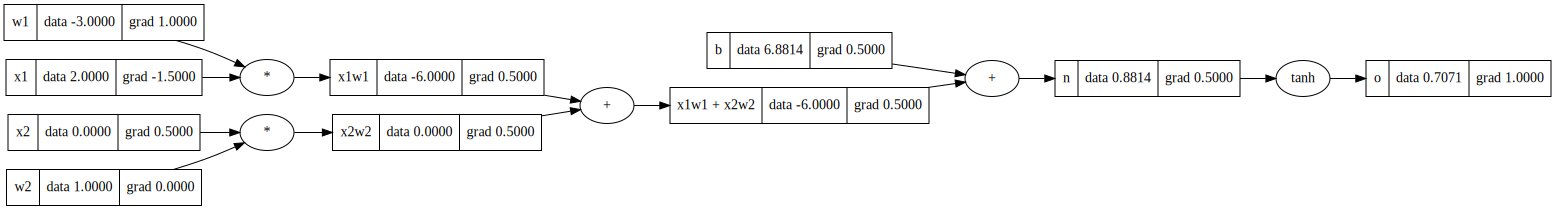

In [38]:
draw_dot(o)

## Automating Backpropagation
Let's try to automate neuron backpropagation using the _backward function in the Value class

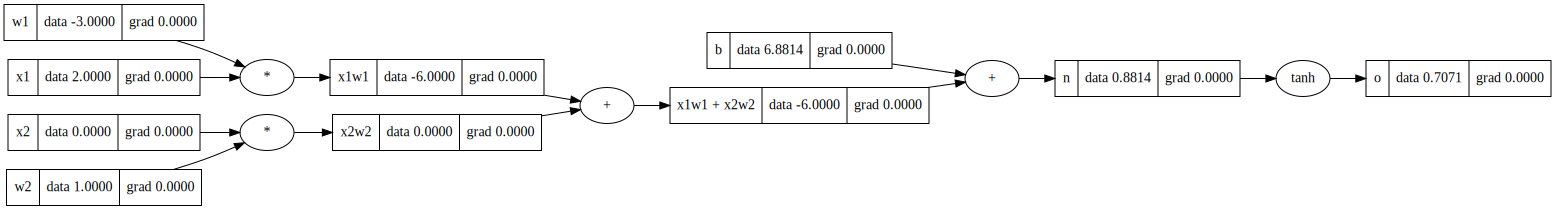

In [56]:
# x1,x2 are the inputs, w1,w2 are our weights and b is our bias, we are going to be using tanh activation function which is hyperbolic
x1 = Value(2,label='x1')
x2 = Value(0,label='x2')

w1 = Value(-3,label='w1')
w2 = Value(1,label='w2')

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'

b = Value(6.8813735870195432,label = 'b')
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

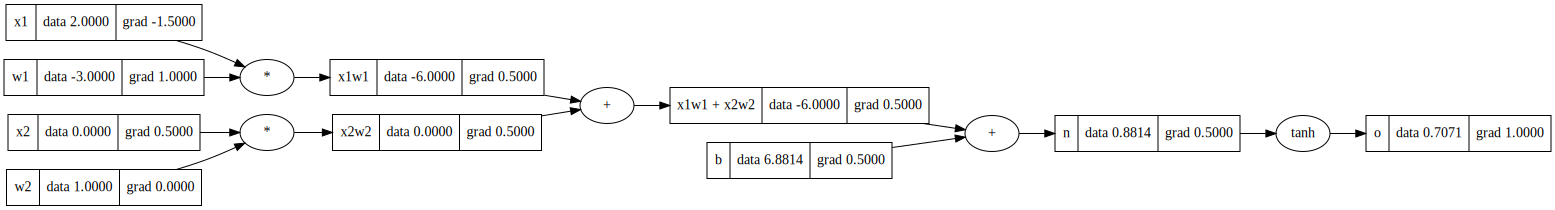

In [48]:
o.grad = 1 # the base case, final grad is always 1
o._backward() # sets grad for n
n._backward() # sets grad for x1w1 + x2w2, b
b._backward() # leaf node has undefined backward so this does nothing
x1w1x2w2._backward() # sets grad for x1w1 and x2w2
x1w1._backward() # sets grad for x1 and w1
x2w2._backward() # sets grad for x2 and w2
draw_dot(o)

Now we need to find a way to automate it even further so we don't need to call individual backward functions each time. so we just add a line to the backward function using a sort of recursion, calling the backwards of both self and other, this line is highlighted in the Value class by the "added later" comments and by default initialising grad to 1.

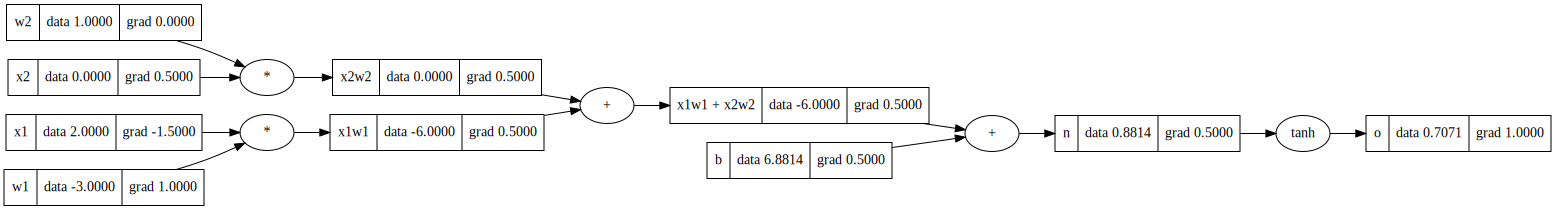

In [54]:
o._backward()
draw_dot(o)

The above approach is only good for an induvidual neuron as in a neural network, each weight / bias etc is connected to multiple nodes and the entire network is one giant directed acyclic graph so calling _backward recursively when one node can be children f multiple nodes can lead to incorrect gradient calculation so we fix this by performing topological sort which orders all nodes in such a way that all edges have the same direction, and no parent appears before their child in that order. Look at the main backwards function in the Value class which implements this.

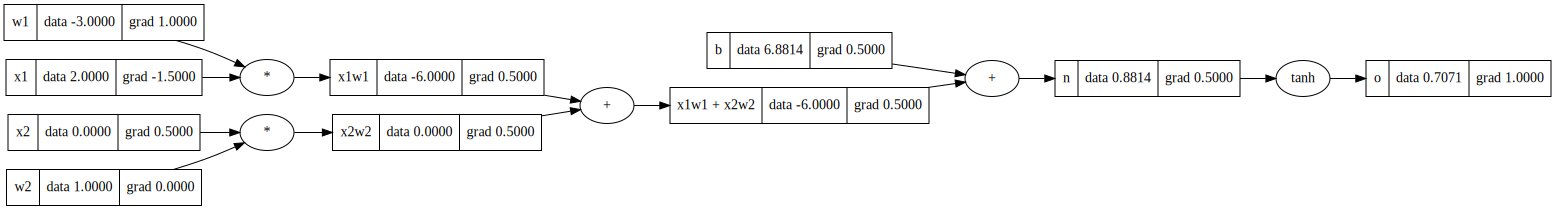

In [57]:
o.backward()
draw_dot(o)

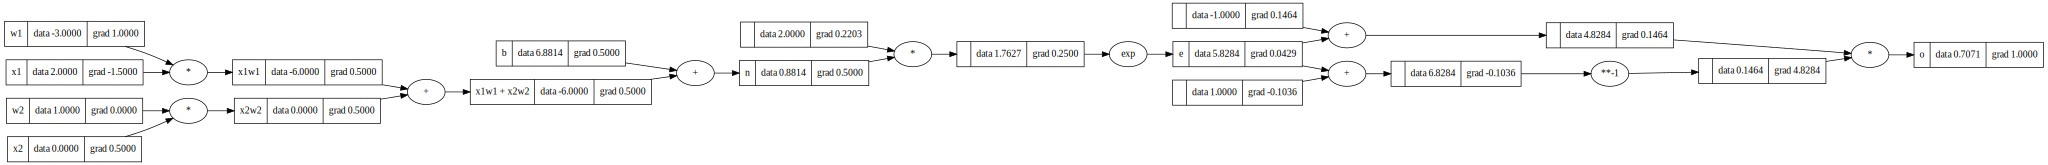

In [61]:
# after adding a bunch of division, exp, pow functions in Value we can substitute tanh with its expression
# x1,x2 are the inputs, w1,w2 are our weights and b is our bias, we are going to be using tanh activation function which is hyperbolic
x1 = Value(2,label='x1')
x2 = Value(0,label='x2')

w1 = Value(-3,label='w1')
w2 = Value(1,label='w2')

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'

b = Value(6.8813735870195432,label = 'b')
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'

n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp(); e.label = 'e'
o = (e-1) / (e+1); o.label = 'o'
o.backward()
draw_dot(o)